# Entrenamiento Binario de Columna Thoracolumbar - Colab

Version para Google Colab del notebook oficial de etapa 1.

Objetivo:
1. entrenar un modelo binario para localizar la columna
2. guardar el mejor checkpoint binario
3. guardar el split oficial train/val/test

Este notebook asume que la carpeta completa del proyecto esta en Google Drive.

## 0. Preparacion de Colab

Ajusta `PROJECT_ROOT` a la carpeta del proyecto dentro de tu Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"No existe la carpeta: {PROJECT_ROOT}")

os.chdir(PROJECT_ROOT)
print("Working directory:", Path.cwd())


Mounted at /content/drive
Working directory: /content/drive/MyDrive/DataRadriografias


## 1. Librerias y configuracion

In [2]:
from __future__ import annotations

import math
import random
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd()
DATASET_ROOT = Path("/content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/data/ScoliosisDataSetYeisson")
LOCAL_CACHE_DIR = Path('/tmp/data_radiografias_colab_cache')
LOCAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

INDEX_PATH = ROOT / 'data' / 'ScoliosisDataSetYeisson' / 'indice_dataset.csv'
MANIFEST_PATH = ROOT / 'analysis_outputs' / 'training_manifest_thoracolumbar.csv'
OUTPUT_DIR = ROOT / 'analysis_outputs' / 'training_runs_binary_thoracolumbar'
MODEL_DIR = ROOT / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not INDEX_PATH.exists():
    raise FileNotFoundError(f'No existe {INDEX_PATH}')
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f'No existe {MANIFEST_PATH}. Primero corre el notebook de analisis en Colab.'
    )

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'

IMG_SIZE = (512, 256)
BATCH_SIZE = 4
NUM_WORKERS = 2
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 14
TEST_RATIO = 0.20
VAL_RATIO_WITHIN_DEV = 0.20
BINARY_THRESHOLD = 0.50

index_df_raw = pd.read_csv(INDEX_PATH)
manifest_df = pd.read_csv(MANIFEST_PATH)

def resolve_dataset_path(rel: str) -> str:
    rel_path = Path(str(rel).replace(chr(92), '/'))
    if rel_path.is_absolute():
        return str(rel_path)
    candidates = [
        ROOT / rel_path,
        DATASET_ROOT / rel_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate.resolve())
    return str((DATASET_ROOT / rel_path).resolve())

index_col_map = {
    'grupo': 'split',
    'imagen': 'image',
    'id_paciente': 'patient_id',
    'ruta_radiografia': 'radiograph_path',
    'ruta_mascara_binaria': 'label_binary_path',
}
index_df = index_df_raw.rename(columns=index_col_map).copy()

join_cols = ['split', 'image', 'patient_id', 'radiograph_path']
dataset_subset = index_df[join_cols + ['label_binary_path']].copy()
train_table = manifest_df.merge(dataset_subset, on=join_cols, how='left')
train_table['radiograph_path_abs'] = train_table['radiograph_path'].apply(resolve_dataset_path)
train_table['binary_mask_path_abs'] = train_table['label_binary_path'].apply(resolve_dataset_path)

for col in ['usable_for_binary_spine', 'needs_annotation_review']:
    if col in train_table.columns:
        train_table[col] = train_table[col].map(
            lambda x: x if isinstance(x, bool) else str(x).strip().lower() == 'true'
        )

binary_df = train_table.loc[train_table['usable_for_binary_spine']].copy()
print('ROOT:', ROOT)
print('DEVICE:', DEVICE)
print('Total muestras:', len(train_table))
print('Muestras para binario:', len(binary_df))
display(binary_df.head())


def safe_copy_to_drive(local_path: Path, destination_path: Path, retries: int = 5, sleep_seconds: float = 2.0) -> None:
    destination_path.parent.mkdir(parents=True, exist_ok=True)
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            shutil.copy2(local_path, destination_path)
            return
        except Exception as exc:
            last_error = exc
            print(f'Intento {attempt}/{retries} fallido copiando a Drive: {destination_path} -> {exc}')
            time.sleep(sleep_seconds)
    raise last_error


def safe_to_csv(df: pd.DataFrame, destination_path: Path, index: bool = False) -> None:
    local_path = LOCAL_CACHE_DIR / destination_path.name
    df.to_csv(local_path, index=index)
    safe_copy_to_drive(local_path, destination_path)


def safe_torch_save(state_dict: dict, destination_path: Path) -> None:
    local_path = LOCAL_CACHE_DIR / destination_path.name
    torch.save(state_dict, local_path)
    safe_copy_to_drive(local_path, destination_path)


ROOT: /content/drive/MyDrive/DataRadriografias
DEVICE: cuda
Total muestras: 250
Muestras para binario: 250


,split,image,patient_id,radiograph_path,mask_path,num_visible_target_vertebrae,first_visible_target,last_visible_target,visible_target_span_signature,present_target_vertebrae,...,present_L4,present_L5,all_core_labels_present,usable_for_binary_spine,usable_for_thoracolumbar_core,usable_for_thoracolumbar_partial,needs_annotation_review,usable_for_cobb_regression,label_binary_path,binary_mask_path_abs
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_1.jpg,/content/drive/MyDrive/DataRadriografias/data/...
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_2.jpg,/content/drive/MyDrive/DataRadriografias/data/...
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_3.jpg,/content/drive/MyDrive/DataRadriografias/data/...
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_4.jpg,/content/drive/MyDrive/DataRadriografias/data/...
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,1,1,True,True,True,True,False,False,LabelBinaryJPG/Label_N_5.jpg,/content/drive/MyDrive/DataRadriografias/data/...


## 2. Split train / val / test

In [3]:
def make_group_train_val_test_split(
    df_in: pd.DataFrame,
    test_ratio: float = 0.20,
    val_ratio_within_dev: float = 0.20,
    seed: int = 42,
) -> pd.DataFrame:
    work = df_in.reset_index(drop=True).copy()
    holdout_splitter = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=seed)
    dev_idx, test_idx = next(holdout_splitter.split(work, groups=work['group_id_for_split']))
    dev_df = work.iloc[dev_idx].copy()
    test_df = work.iloc[test_idx].copy()

    val_splitter = GroupShuffleSplit(n_splits=1, test_size=val_ratio_within_dev, random_state=seed)
    train_idx, val_idx = next(val_splitter.split(dev_df, groups=dev_df['group_id_for_split']))
    train_df = dev_df.iloc[train_idx].copy()
    val_df = dev_df.iloc[val_idx].copy()

    train_df['partition'] = 'train'
    val_df['partition'] = 'val'
    test_df['partition'] = 'test'
    return pd.concat([train_df, val_df, test_df], ignore_index=True)


binary_splits_df = make_group_train_val_test_split(binary_df, test_ratio=TEST_RATIO, val_ratio_within_dev=VAL_RATIO_WITHIN_DEV, seed=SEED)

split_path = OUTPUT_DIR / 'binary_spine_split_train_val_test.csv'
group_map_path = OUTPUT_DIR / 'binary_spine_group_partition_map.csv'
safe_to_csv(binary_splits_df, split_path, index=False)
group_partition_df = (
    binary_splits_df[['group_id_for_split', 'partition']]
    .drop_duplicates()
    .sort_values(['partition', 'group_id_for_split'])
    .copy()
)
safe_to_csv(group_partition_df, group_map_path, index=False)

display(binary_splits_df.groupby(['partition', 'split']).size().rename('images').reset_index())
display(binary_splits_df.groupby('partition')['group_id_for_split'].nunique().rename('groups').reset_index())

,partition,split,images
0,test,Normal,18
1,test,Scoliosis,32
2,train,Normal,47
3,train,Scoliosis,113
4,val,Normal,6
5,val,Scoliosis,34


,partition,groups
0,test,50
1,train,160
2,val,40


## 3. Dataset, arquitectura y metricas

In [4]:
def read_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert('L'))


def resize_image(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((size[1], size[0]), resample=Image.BILINEAR))


def resize_mask(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((size[1], size[0]), resample=Image.NEAREST))


def build_binary_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = read_gray(path)
    mask = (mask >= 127).astype(np.uint8)
    if size is not None:
        mask = resize_mask(mask, size)
    return mask


class BinarySpineDataset(Dataset):
    def __init__(self, table: pd.DataFrame, image_size: tuple[int, int]):
        self.table = table.reset_index(drop=True).copy()
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.table)

    def __getitem__(self, idx: int) -> dict:
        row = self.table.iloc[idx]
        image_raw = read_gray(row['radiograph_path_abs'])
        image_resized = resize_image(image_raw, self.image_size).astype(np.float32) / 255.0
        image_resized = np.expand_dims(image_resized, axis=0)
        mask = build_binary_mask(row['binary_mask_path_abs'], size=self.image_size).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)
        return {
            'image': torch.tensor(image_resized, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'sample_id': row['unique_sample_id'],
        }


class DoubleConv(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_channels, base)
        self.e2 = DoubleConv(base, base * 2)
        self.e3 = DoubleConv(base * 2, base * 4)
        self.e4 = DoubleConv(base * 4, base * 8)
        self.b = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConv(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)


def dice_loss_binary(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    denominator = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1.0 - dice.mean()


def evaluate_binary(model: nn.Module, loader: DataLoader, bce_loss: nn.Module) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_batches = 0
    intersection = 0.0
    pred_area = 0.0
    target_area = 0.0
    correct = 0.0
    total_pixels = 0.0
    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(DEVICE)
            targets = batch['mask'].to(DEVICE)
            logits = model(images)
            loss = bce_loss(logits, targets) + dice_loss_binary(logits, targets)
            total_loss += float(loss.item())
            total_batches += 1
            preds = (torch.sigmoid(logits) >= BINARY_THRESHOLD).float()
            intersection += float((preds * targets).sum().item())
            pred_area += float(preds.sum().item())
            target_area += float(targets.sum().item())
            correct += float((preds == targets).sum().item())
            total_pixels += float(targets.numel())
    union = pred_area + target_area - intersection
    return {
        'loss': total_loss / max(total_batches, 1),
        'dice': (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6),
        'iou': (intersection + 1e-6) / (union + 1e-6),
        'pixel_accuracy': (correct + 1e-6) / (total_pixels + 1e-6),
    }


def plot_history(history_df: pd.DataFrame, title: str) -> None:
    metric_cols = [col for col in history_df.columns if col != 'epoch']
    ncols = 2
    nrows = int(math.ceil(len(metric_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, max(4, 4 * nrows)))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, metric_cols):
        ax.plot(history_df['epoch'], history_df[col], marker='o')
        ax.set_title(col)
        ax.set_xlabel('epoch')
        ax.grid(True, alpha=0.3)
    for ax in axes[len(metric_cols):]:
        ax.axis('off')
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Entrenamiento binario

[Binary][Epoch 01/14] train_dice=0.3485 val_dice=0.3746
[Binary][Epoch 02/14] train_dice=0.4668 val_dice=0.5325
[Binary][Epoch 03/14] train_dice=0.6813 val_dice=0.6688
[Binary][Epoch 04/14] train_dice=0.5552 val_dice=0.4715
[Binary][Epoch 05/14] train_dice=0.7276 val_dice=0.6819
[Binary][Epoch 06/14] train_dice=0.8379 val_dice=0.8157
[Binary][Epoch 07/14] train_dice=0.8245 val_dice=0.7835
[Binary][Epoch 08/14] train_dice=0.7864 val_dice=0.7844
[Binary][Epoch 09/14] train_dice=0.8176 val_dice=0.7809
[Binary][Epoch 10/14] train_dice=0.7381 val_dice=0.7008
[Binary][Epoch 11/14] train_dice=0.8506 val_dice=0.8310
[Binary][Epoch 12/14] train_dice=0.8366 val_dice=0.8171
[Binary][Epoch 13/14] train_dice=0.6740 val_dice=0.6684
[Binary][Epoch 14/14] train_dice=0.8703 val_dice=0.8469
Checkpoint guardado en: /content/drive/MyDrive/DataRadriografias/models/binary_spine_thoracolumbar_best.pt
Tiempo total (min): 4.28
Mejor val_dice: 0.8469


,epoch,train_loss,train_dice,train_iou,train_pixel_accuracy,val_loss,val_dice,val_iou,val_pixel_accuracy
9,10,0.530900,0.738072,0.584876,0.929269,0.588512,0.700836,0.539452,0.921302
10,11,0.341952,0.850566,0.739987,0.952656,0.387325,0.830982,0.710838,0.947855
11,12,0.339298,0.836582,0.719073,0.953925,0.380567,0.817092,0.690748,0.950107
12,13,0.666231,0.674004,0.508300,0.923320,0.671142,0.668405,0.501958,0.924072
13,14,0.279967,0.870289,0.770365,0.962070,0.328903,0.846941,0.734517,0.956976


,loss,dice,iou,pixel_accuracy
0,0.320879,0.852171,0.74242,0.957025


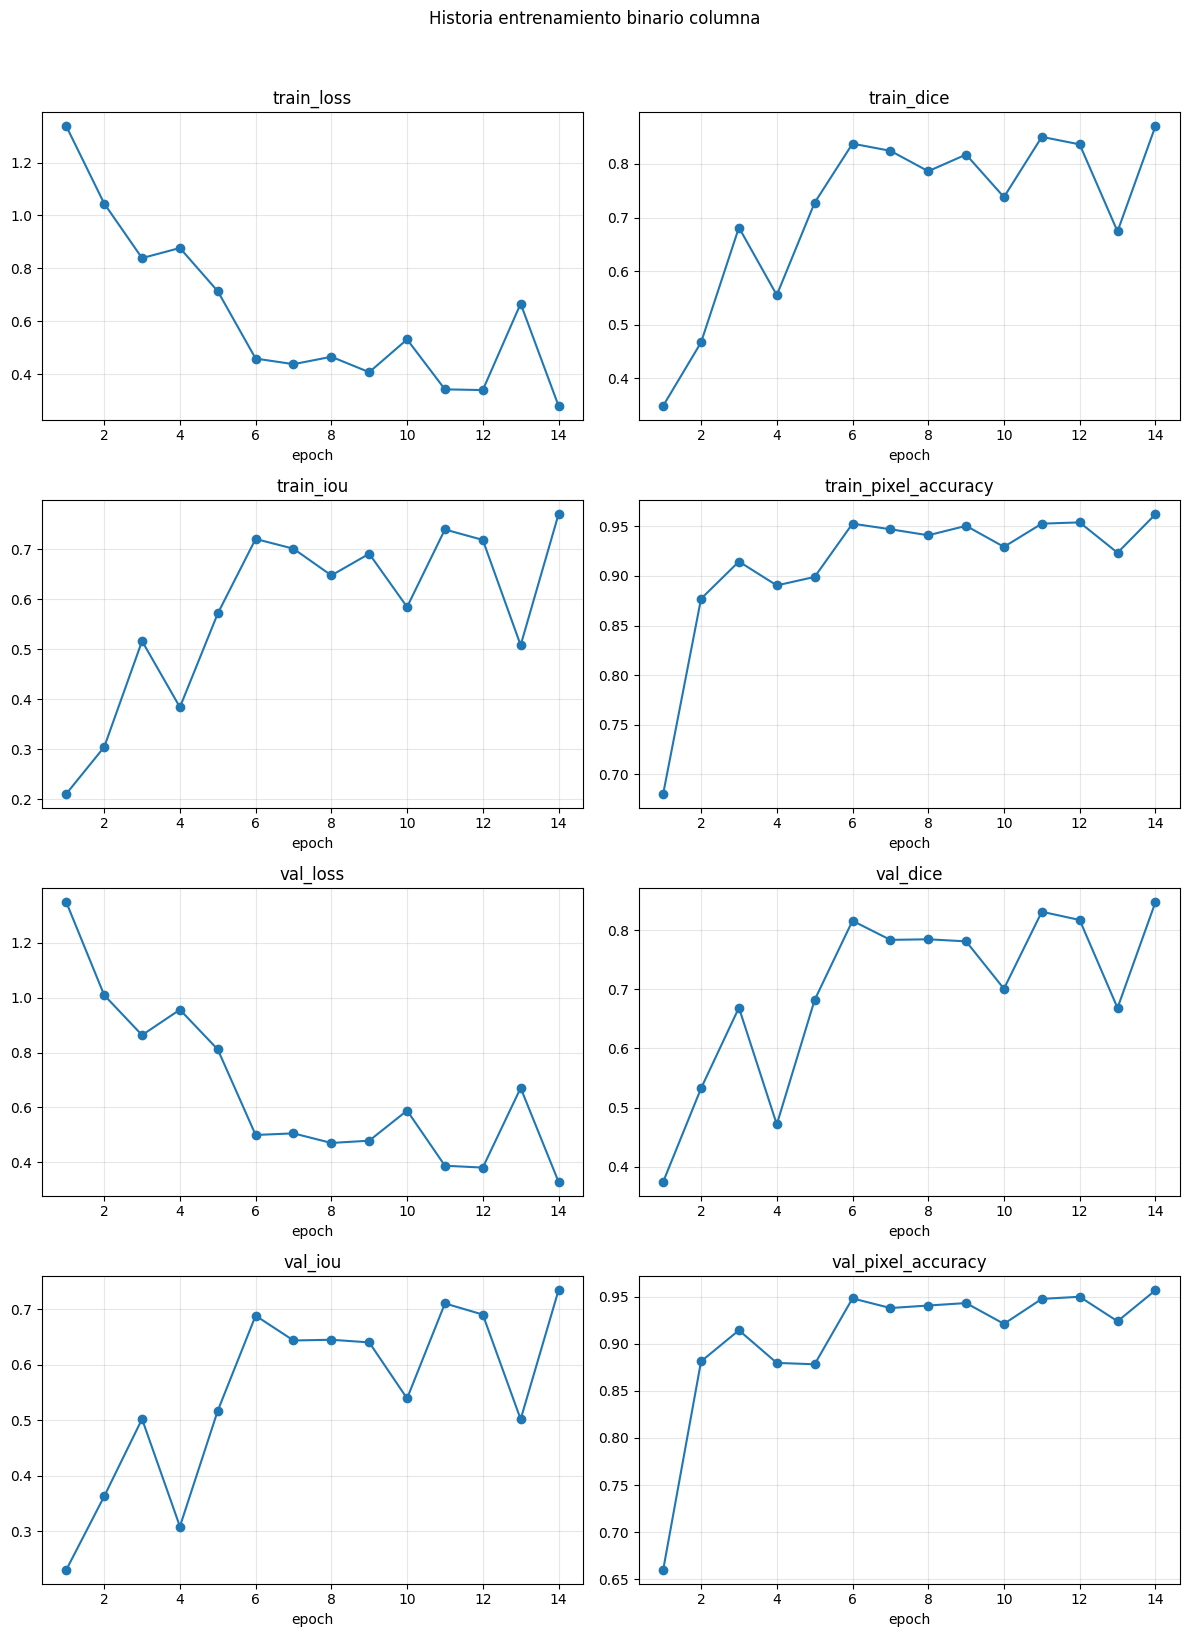

In [5]:
train_ds = BinarySpineDataset(binary_splits_df.query("partition == 'train'"), image_size=IMG_SIZE)
val_ds = BinarySpineDataset(binary_splits_df.query("partition == 'val'"), image_size=IMG_SIZE)
test_ds = BinarySpineDataset(binary_splits_df.query("partition == 'test'"), image_size=IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

binary_model = UNetSmall(in_channels=1, out_channels=1).to(DEVICE)
binary_optimizer = torch.optim.AdamW(binary_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
binary_bce = nn.BCEWithLogitsLoss()

history = []
best_state = None
best_val_dice = -1.0
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    binary_model.train()
    for batch in train_loader:
        images = batch['image'].to(DEVICE)
        targets = batch['mask'].to(DEVICE)
        binary_optimizer.zero_grad()
        logits = binary_model(images)
        loss = binary_bce(logits, targets) + dice_loss_binary(logits, targets)
        loss.backward()
        binary_optimizer.step()

    train_metrics = evaluate_binary(binary_model, train_loader, binary_bce)
    val_metrics = evaluate_binary(binary_model, val_loader, binary_bce)
    history.append({
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_dice': train_metrics['dice'],
        'train_iou': train_metrics['iou'],
        'train_pixel_accuracy': train_metrics['pixel_accuracy'],
        'val_loss': val_metrics['loss'],
        'val_dice': val_metrics['dice'],
        'val_iou': val_metrics['iou'],
        'val_pixel_accuracy': val_metrics['pixel_accuracy'],
    })
    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        best_state = {k: v.detach().cpu().clone() for k, v in binary_model.state_dict().items()}
    print(f"[Binary][Epoch {epoch:02d}/{EPOCHS}] train_dice={train_metrics['dice']:.4f} val_dice={val_metrics['dice']:.4f}")

history_df = pd.DataFrame(history)
binary_model.load_state_dict(best_state)
test_metrics = evaluate_binary(binary_model, test_loader, binary_bce)

model_path = MODEL_DIR / 'binary_spine_thoracolumbar_best.pt'
metrics_path = OUTPUT_DIR / 'binary_spine_test_metrics.csv'
history_path = OUTPUT_DIR / 'binary_spine_history.csv'
safe_torch_save(binary_model.state_dict(), model_path)
safe_to_csv(pd.DataFrame([test_metrics]), metrics_path, index=False)
safe_to_csv(history_df, history_path, index=False)

print('Checkpoint guardado en:', model_path)
print('Tiempo total (min):', round((time.time() - start_time) / 60.0, 2))
print('Mejor val_dice:', round(best_val_dice, 4))
display(history_df.tail())
display(pd.DataFrame([test_metrics]))
plot_history(history_df, 'Historia entrenamiento binario columna')

## 5. Revision cualitativa

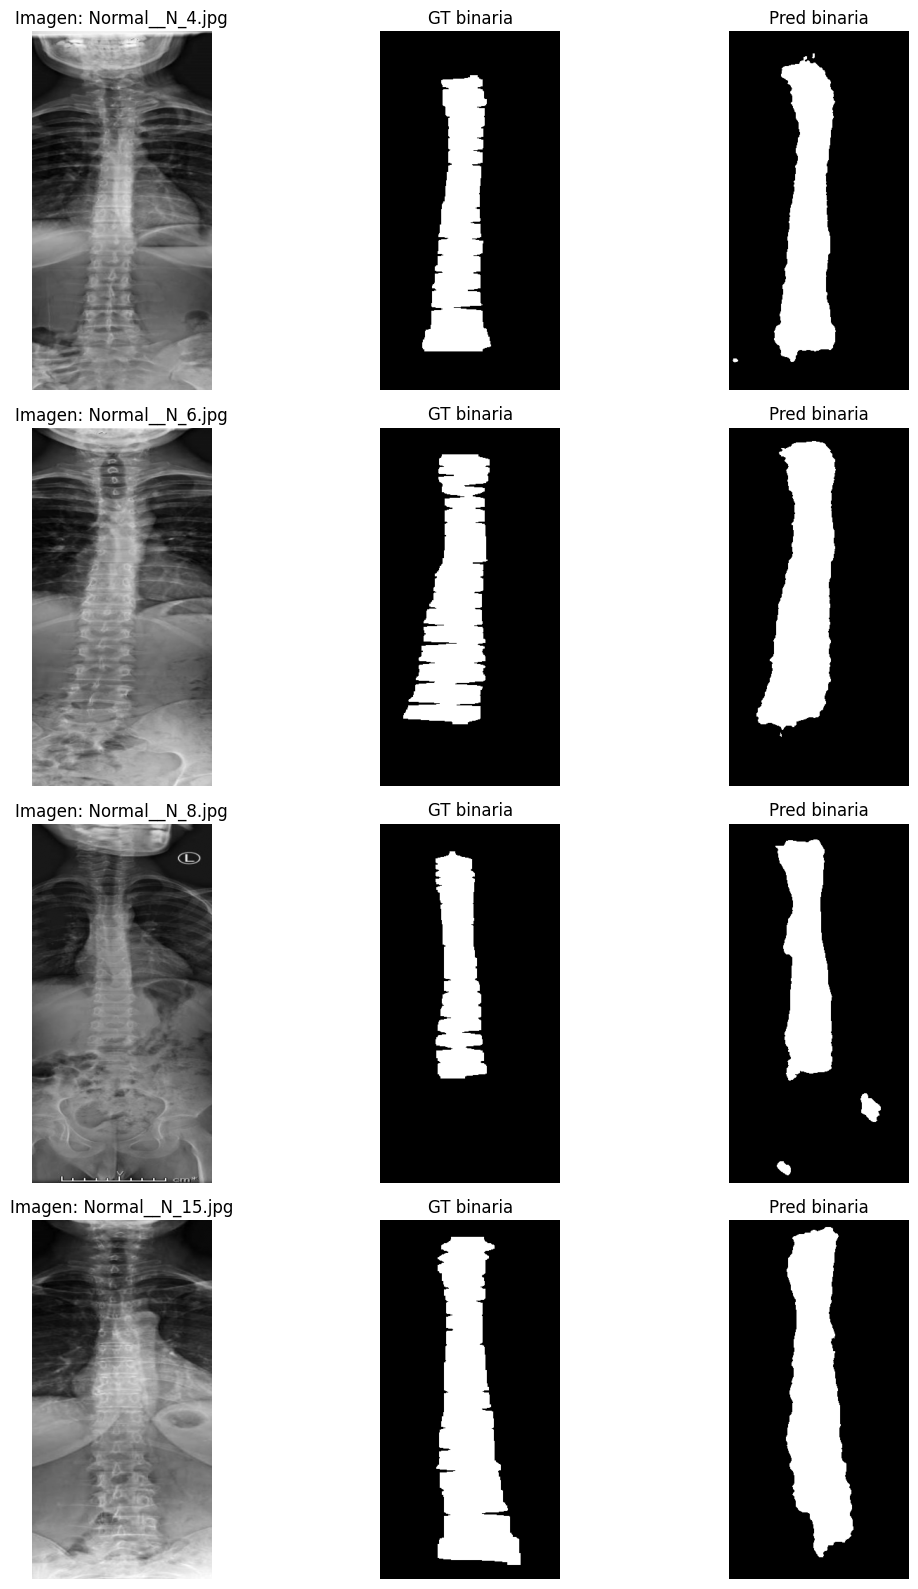

In [6]:
def show_binary_predictions(model: nn.Module, dataset: Dataset, n: int = 4) -> None:
    model.eval()
    n = min(n, len(dataset))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for idx in range(n):
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(DEVICE)
            target = sample['mask'][0].numpy()
            pred = (torch.sigmoid(model(image))[0, 0].detach().cpu().numpy() >= BINARY_THRESHOLD).astype(np.uint8)
            axes[idx, 0].imshow(sample['image'][0].numpy(), cmap='gray')
            axes[idx, 0].set_title(f"Imagen: {sample['sample_id']}")
            axes[idx, 1].imshow(target, cmap='gray')
            axes[idx, 1].set_title('GT binaria')
            axes[idx, 2].imshow(pred, cmap='gray')
            axes[idx, 2].set_title('Pred binaria')
            for j in range(3):
                axes[idx, j].axis('off')
    plt.tight_layout()
    plt.show()


show_binary_predictions(binary_model, test_ds, n=4)